# Algorithm 1 on recorded trajectory ensembles

This notebook runs the constraint estimation and the decomposed gains of the paper (Algorithm 1) on four
trajectory ensembles recorded in the simulation evaluation (Section 5.1), one per object. Each ensemble
holds N = 128 trajectories of H = 24 waypoints, 0.1 s apart, that the released per-object policy sampled
at grasp closure, together with the TCP and object poses at that instant
(`data/<object>_ensemble.npz`; all poses in the environment frame of the trial).

Neither the simulator nor the policy is needed:

```bash
pip install -e ".[examples]"    # the method package, matplotlib and Jupyter
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import SymLogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from con_dec_imp.estimator import gains_from_estimate, twist_matrix
from con_dec_imp.gains import inertia_metric
from con_dec_imp.lie import quat_to_matrix
from con_dec_imp.metrics import principal_angles, subspace_error
from con_dec_imp.policy.actions import GRIPPER_CLOSED_THRESHOLD, chunk_to_transforms
from con_dec_imp.settings import ESTIMATION, GAINS
from con_dec_imp.subspace import estimate_subspace
from con_dec_imp_sim import OBJECTS
from con_dec_imp_sim.reference import EVALUATION_LENGTH, GENERATORS, reference_basis

DATA = Path("data")  # examples/data, relative to this notebook
TWIST_LABELS = [r"$\omega_x$", r"$\omega_y$", r"$\omega_z$", r"$v_x$", r"$v_y$", r"$v_z$"]
plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

ensembles = {}
for name in OBJECTS:
    with np.load(DATA / f"{name}_ensemble.npz") as data:
        ensembles[name] = {key: torch.from_numpy(data[key]) for key in data.files}
    chunks = ensembles[name]["chunks"]  # (N, H, 10): position, 6-D rotation, gripper command
    print(f"{name:12s} {chunks.shape[0]} trajectories x {chunks.shape[1]} waypoints")

revolute     128 trajectories x 24 waypoints
cylindrical  128 trajectories x 24 waypoints
planar       128 trajectories x 24 waypoints
universal    128 trajectories x 24 waypoints


## 1. The ensembles

The plots show the TCP positions of the 128 sampled trajectories in the object root frame, together with
the TCP at sampling and the joint axes of each mechanism: dashed lines are rotation axes and arrows are
translation directions. The rotation axis of the planar joint moves with the handle, so it is drawn
through the TCP. Every waypoint of these ensembles commands a closed gripper.

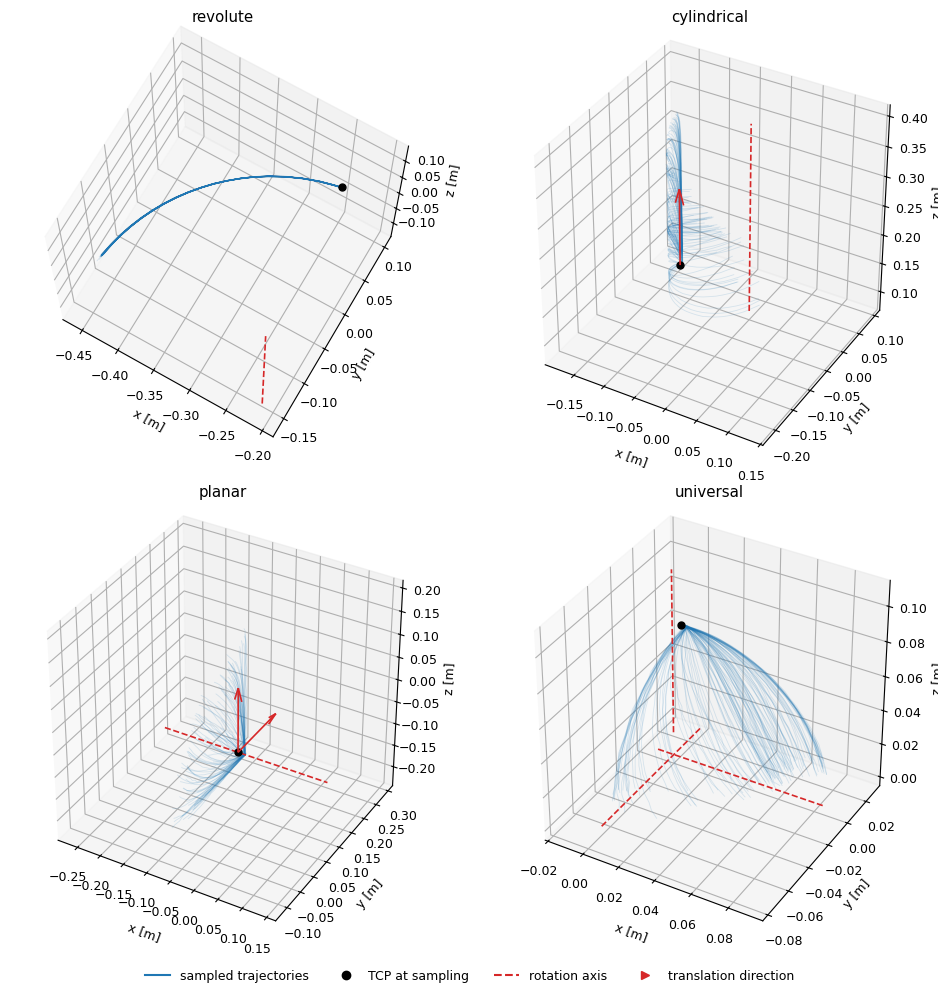

In [2]:
def object_frame(name: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # TCP paths (N, H, 3) of the samples and the TCP position (3,) and orientation (3, 3) at sampling,
    # all in the object root frame.
    data = ensembles[name]
    R_obj, p_obj = quat_to_matrix(data["object_pose"][3:7]).numpy(), data["object_pose"][:3].numpy()
    paths = (data["chunks"][..., :3].double().numpy() - p_obj) @ R_obj
    start = (data["tcp_pose"][:3].numpy() - p_obj) @ R_obj
    R_tcp = R_obj.T @ quat_to_matrix(data["tcp_pose"][3:7]).numpy()
    return paths, start, R_tcp


def set_view(ax, name: str, drawn: np.ndarray) -> None:
    # Equal axis scales around the drawn points; the revolute door swings in a horizontal plane.
    center, half = (drawn.min(0) + drawn.max(0)) / 2, 0.55 * np.ptp(drawn, axis=0).max()
    ax.set(xlim=(center[0] - half, center[0] + half), ylim=(center[1] - half, center[1] + half),
           zlim=(center[2] - half, center[2] + half), xlabel="x [m]", ylabel="y [m]", zlabel="z [m]")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=70 if name == "revolute" else 35, azim=-60)
    ax.set_title(name)


fig = plt.figure(figsize=(10, 10))
for i, name in enumerate(OBJECTS):
    paths, start, _ = object_frame(name)
    points = paths.reshape(-1, 3)
    length = np.ptp(points, axis=0).max()

    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    for path in paths:
        ax.plot(*path.T, color="tab:blue", alpha=0.15, lw=0.6)
    ax.scatter(*start, color="black", s=25, depthshade=False)
    drawn = [points, start[None]]
    for generator in GENERATORS[name]:
        axis = np.array(generator.axis)
        if generator.kind == "rotation":
            point = start if name == "planar" else np.array(generator.point)
            center = point + axis * (axis @ (points.mean(axis=0) - point))
            ends = np.stack([center - 0.6 * length * axis, center + 0.6 * length * axis])
            ax.plot(*ends.T, "--", color="tab:red", lw=1.2)
            drawn.append(ends)
        else:
            ax.quiver(*start, *(0.5 * length * axis), color="tab:red", lw=1.2, arrow_length_ratio=0.2)
            drawn.append((start + 0.5 * length * axis)[None])
    set_view(ax, name, np.concatenate(drawn))

fig.legend(
    [Line2D([], [], color="tab:blue"), Line2D([], [], color="black", marker="o", ls=""),
     Line2D([], [], color="tab:red", ls="--"), Line2D([], [], color="tab:red", marker=">", ls="")],
    ["sampled trajectories", "TCP at sampling", "rotation axis", "translation direction"],
    loc="lower center", ncol=4, frameon=False,
)
fig.subplots_adjust(left=0.02, right=0.95, bottom=0.06, top=0.96, wspace=0.1, hspace=0.12)
plt.show()

## 2. Twist matrix and weighted PCA (Algorithm 1, lines 3-8)

Each trajectory gives a body twist $V = (\omega, v)$ at every waypoint by finite differences on SE(3), and
the twists of all samples form the twist matrix $W$ ($6 \times M$, here $M = NH = 3072$). Only waypoints
that command a closed gripper enter $W$. The characteristic length is
$\alpha = \mathrm{clip}(\lVert u_v \rVert / \lVert u_\omega \rVert, 0.03, 0.5)$ m, with $u$ the first left
singular vector of $W$. The weighted PCA in the metric $G = \mathrm{blkdiag}(\alpha^2 I_3, I_3)$ gives the
principal directions $u_k$ and $\lambda_k = \tilde\sigma_k^2 / M$, so $\sqrt{\lambda_k}$ is the RMS speed
along $u_k$.

In [3]:
estimates = {}
for name in OBJECTS:
    chunks = ensembles[name]["chunks"]
    grasped = chunks[..., 9] > GRIPPER_CLOSED_THRESHOLD  # (N, H) waypoints commanding a closed gripper
    W = twist_matrix(chunk_to_transforms(chunks), ESTIMATION.dt, grasped)
    estimates[name] = estimate_subspace(W)
    print(f"{name:12s} W: {tuple(W.shape)}   alpha = {float(estimates[name].alpha):.4f} m")

revolute     W: (6, 3072)   alpha = 0.2385 m
cylindrical  W: (6, 3072)   alpha = 0.1503 m
planar       W: (6, 3072)   alpha = 0.0771 m
universal    W: (6, 3072)   alpha = 0.0777 m


## 3. Dimension selection (line 9)

The feasible dimension counts the directions whose RMS speed clears both a relative and an absolute
threshold, $m = \#\{k : \sqrt{\lambda_k} > \max(\kappa_\mathrm{rel}\sqrt{\lambda_6},\, v_\mathrm{abs})\}$, with
$\kappa_\mathrm{rel} = 4$ and $v_\mathrm{abs} = 5$ mm/s in simulation. The selected directions (blue) span
the estimated feasible subspace.

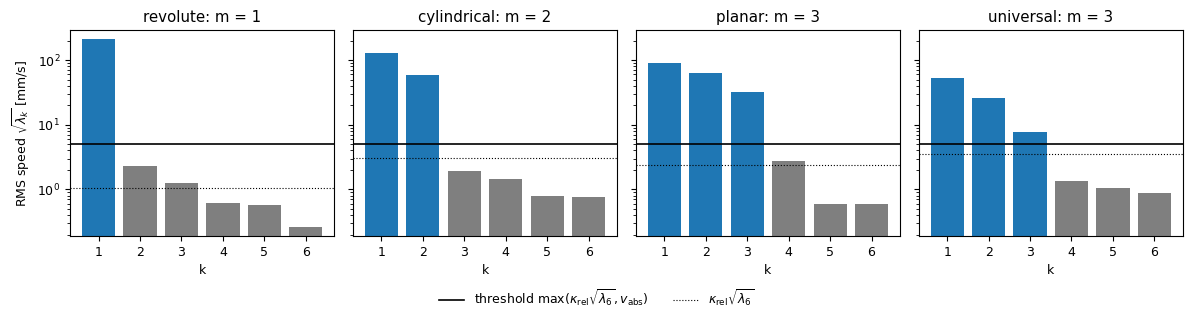

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), sharey=True)
for ax, name in zip(axes, OBJECTS):
    estimate = estimates[name]
    speeds = 1000.0 * estimate.rms_speeds.numpy()  # mm/s
    relative = ESTIMATION.kappa_rel * speeds[-1]
    threshold = max(relative, 1000.0 * ESTIMATION.v_abs)
    m = int(estimate.dim)
    ax.bar(range(1, 7), speeds, color=["tab:blue" if k < m else "tab:gray" for k in range(6)])
    ax.axhline(threshold, color="black", lw=1.2)
    ax.axhline(relative, color="black", lw=0.8, ls=":")
    ax.set(yscale="log", xticks=range(1, 7), xlabel="k", title=f"{name}: m = {m}")
axes[0].set_ylabel(r"RMS speed $\sqrt{\lambda_k}$ [mm/s]")
fig.legend(
    [Line2D([], [], color="black", lw=1.2), Line2D([], [], color="black", lw=0.8, ls=":")],
    [r"threshold $\max(\kappa_\mathrm{rel}\sqrt{\lambda_6}, v_\mathrm{abs})$", r"$\kappa_\mathrm{rel}\sqrt{\lambda_6}$"],
    loc="lower center", ncol=2, frameon=False,
)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

## 4. Comparison with the reference subspace

The reference subspace is the analytic feasible subspace of the mechanism at this grasp
(`con_dec_imp_sim.reference`). The subspace error SE is the largest principal angle between the estimated
and the reference subspace in the metric $\mathrm{blkdiag}(\alpha^{*2} I_3, I_3)$, with a fixed evaluation
length $\alpha^*$ per object (Appendix H); subspaces of different dimension score 90°.

In [5]:
print(f"{'object':12s} {'m':>2s} {'reference':>9s} {'alpha* [m]':>10s}   principal angles [deg]   SE [deg]")
for name in OBJECTS:
    data = ensembles[name]
    U_est = estimates[name].basis().double().numpy()
    U_ref = reference_basis(name, data["tcp_pose"], data["object_pose"]).numpy()
    alpha_ref = EVALUATION_LENGTH[name]
    angles = principal_angles(U_est, U_ref, alpha_ref) if U_est.shape[1] == U_ref.shape[1] else []
    angles = "  ".join(f"{angle:.2f}" for angle in angles)
    print(f"{name:12s} {U_est.shape[1]:2d} {U_ref.shape[1]:9d} {alpha_ref:10.4f}   {angles:22s}"
          f"   {subspace_error(U_est, U_ref, alpha_ref):.2f}")

object        m reference alpha* [m]   principal angles [deg]   SE [deg]
revolute      1         1     0.2425   1.21                     1.21
cylindrical   2         2     0.1534   0.19  1.57               1.57
planar        3         3     0.1350   0.03  0.70  1.14         1.14
universal     3         3     0.0653   0.12  2.27  3.19         3.19


## 5. Decomposed gains (lines 10-11)

With the metric-orthogonal projectors $P_\parallel = U(U^\top \bar\Lambda U)^{-1} U^\top \bar\Lambda$ and
$P_\perp = I - P_\parallel$ in the normalized inertia metric $\bar\Lambda = \mathrm{blkdiag}(l^2 I_3, I_3)$, the
stiffness is $K_v = \bar\Lambda(k_0 P_\parallel + r k_0 P_\perp)$ with $k_0 = 250$ and $r = 0.1$; the damping
$D_v$ has the same structure. Iso uses $K_v = k_0 \bar\Lambda$: 250 for translation and $250\,l^2 = 2.65$ for
rotation. The decomposed gains keep this stiffness along the estimated feasible directions and reduce it
to a tenth along the complement. Off-diagonal terms appear where a feasible direction combines
rotation and translation, as in the swing of the door.

revolute     K_v modal stiffness: 250  25  25  25  25  25
cylindrical  K_v modal stiffness: 250  250  25  25  25  25
planar       K_v modal stiffness: 250  250  250  25  25  25
universal    K_v modal stiffness: 250  250  250  25  25  25


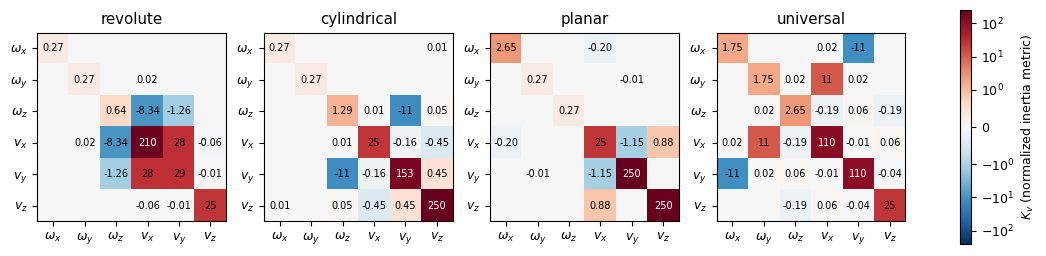

In [6]:
metric = inertia_metric().double().numpy()
stiffness = {name: gains_from_estimate(estimates[name], inertia_metric())[0].double().numpy() for name in OBJECTS}
norm = SymLogNorm(linthresh=1.0, vmin=-250.0, vmax=250.0)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, name in zip(axes, OBJECTS):
    K = stiffness[name]
    # Stiffness per unit metric: k0 along the m feasible directions, r k0 along the complement.
    modal = np.sort(np.linalg.eigvals(np.linalg.solve(metric, K)).real)[::-1]
    print(f"{name:12s} K_v modal stiffness: " + "  ".join(f"{value:.0f}" for value in modal))
    image = ax.imshow(K, cmap="RdBu_r", norm=norm)
    for (row, col), value in np.ndenumerate(K):
        if abs(value) >= 0.005:
            ax.text(col, row, f"{value:.0f}" if abs(value) >= 10 else f"{value:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if abs(value) > 100 else "black")
    ax.set_xticks(range(6), TWIST_LABELS)
    ax.set_yticks(range(6), TWIST_LABELS)
    ax.set_title(name)
fig.colorbar(image, ax=axes, shrink=0.8, label=r"$K_v$ (normalized inertia metric)")
plt.show()

## 6. The gains on the ensemble

The high-gain directions of $K_v$ are its generalized eigenvectors with $K_v u = k_0 \bar\Lambda u$; they span
the estimated feasible subspace, and the stiffness along the $\bar\Lambda$-orthogonal complement is $r k_0$. As on the
project page, the plots draw this high-gain subspace at the TCP, split into a linear part (blue: a line, a
plane or all directions of translation) and an angular part (purple: rotation axes). Each part keeps the
singular directions of its block of an orthonormal basis in the PCA metric that exceed a tenth of the
largest. The split is for display only and leaves out the coupling of rotation and translation in $K_v$:
for the revolute object, the single feasible direction is the swing about the hinge, a translation along
the handle path together with a rotation about the hinge direction. Along every other direction the
gripper is compliant (×0.1).

revolute     linear part: a line          angular part: one axis
cylindrical  linear part: a plane         angular part: one axis


planar       linear part: a plane         angular part: one axis
universal    linear part: a plane         angular part: all three axes


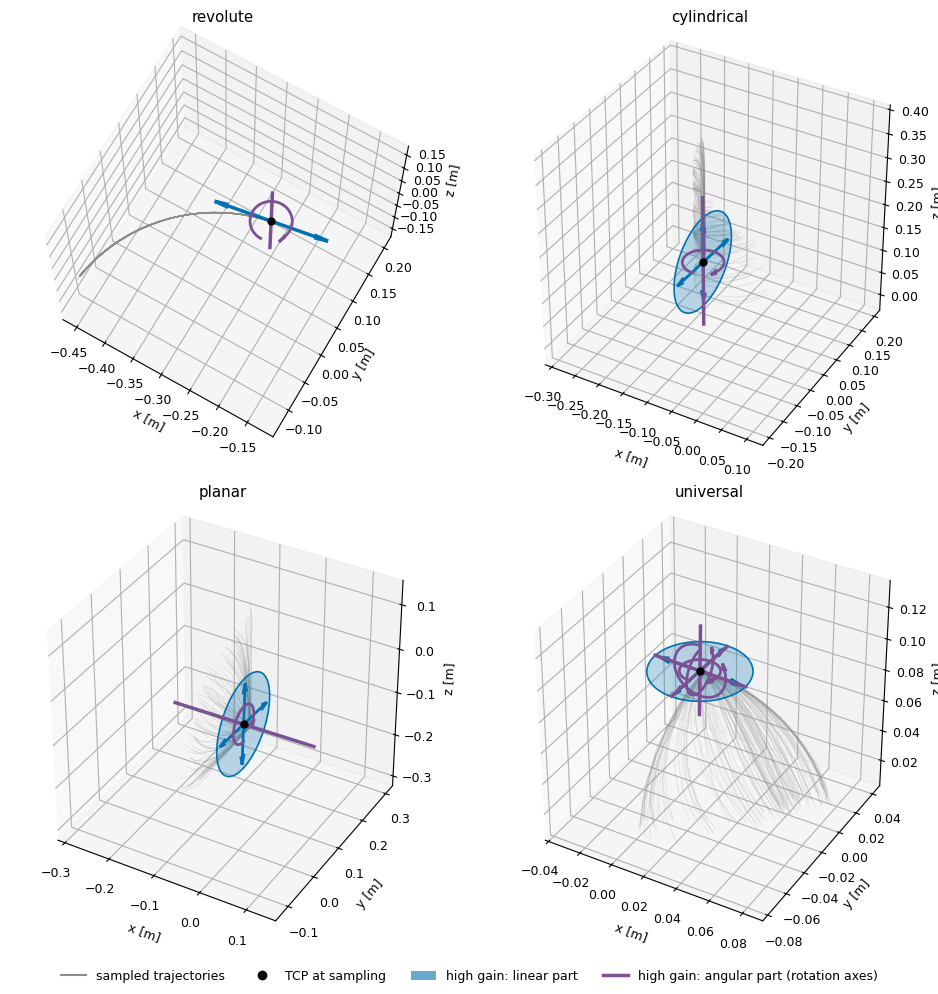

In [7]:
BLUE, PURPLE = "#0072b2", "#7a5195"
SPAN_WORDS = {"linear": ("none", "a line", "a plane", "all directions"),
              "angular": ("none", "one axis", "two axes", "all three axes")}


def high_gain_parts(K: np.ndarray, alpha: float, tol: float = 0.1) -> dict[str, np.ndarray]:
    # Generalized eigenvectors K u = kappa Lam u (Lam diagonal): kappa = k0 on the feasible subspace and
    # r k0 on its complement.
    scale = np.sqrt(np.diag(metric))
    kappa, Y = np.linalg.eigh(K / np.outer(scale, scale))
    U = Y[:, kappa > 0.5 * (1.0 + GAINS.reduction_ratio) * GAINS.k0] / scale[:, None]
    # Orthonormal basis of the high-gain subspace in the PCA metric: rows (alpha omega, v).
    Q, _ = np.linalg.qr(np.diag([alpha] * 3 + [1.0] * 3) @ U)
    parts = {}
    for part, block in (("angular", Q[:3]), ("linear", Q[3:])):
        directions, sv, _ = np.linalg.svd(block)
        parts[part] = directions[:, : int((sv > tol * sv.max()).sum())]  # TCP body frame
    return parts


def double_arrow(ax, origin, direction, half, **style):
    for sign in (1.0, -1.0):
        ax.quiver(*origin, *(sign * half * direction), arrow_length_ratio=0.25, **style)


def draw_high_gain(ax, origin, linear, angular, size):
    # Linear part: a double arrow for a line, a disk for a plane, a sphere for all directions.
    t = np.linspace(0.0, 2.0 * np.pi, 73)
    if linear.shape[1] == 1:
        double_arrow(ax, origin, linear[:, 0], size, color=BLUE, lw=2.5, zorder=5)
    elif linear.shape[1] == 2:
        rim = origin + 0.9 * size * (np.outer(np.cos(t), linear[:, 0]) + np.outer(np.sin(t), linear[:, 1]))
        ax.add_collection3d(Poly3DCollection([rim], facecolor=BLUE, alpha=0.25, zorder=4))
        ax.plot(*rim.T, color=BLUE, lw=1.2, zorder=5)
        for direction in linear.T:
            double_arrow(ax, origin, direction, 0.8 * size, color=BLUE, lw=2.0, zorder=5)
    elif linear.shape[1] == 3:
        u, v = np.meshgrid(t, np.linspace(0.0, np.pi, 19))
        sphere = 0.8 * size * np.stack([np.cos(u) * np.sin(v), np.sin(u) * np.sin(v), np.cos(v)])
        ax.plot_surface(*(origin[:, None, None] + sphere), color=BLUE, alpha=0.15, lw=0, zorder=4)
    # Angular part: each rotation axis through the TCP, with a curl about it.
    for k, axis in enumerate(angular.T):
        half = (1.3 if angular.shape[1] == 1 else 0.9) * size
        ax.plot(*(origin + np.outer([-half, half], axis)).T, color=PURPLE, lw=2.5, zorder=6)
        e1 = np.cross(axis, [1.0, 0.0, 0.0] if abs(axis[0]) < 0.9 else [0.0, 1.0, 0.0])
        e1 /= np.linalg.norm(e1)
        e2 = np.cross(axis, e1)
        s = np.linspace(0.0, 1.6 * np.pi, 60)
        arc = origin + (0.35 + 0.08 * k) * size * (np.outer(np.cos(s), e1) + np.outer(np.sin(s), e2))
        ax.plot(*arc.T, color=PURPLE, lw=2.0, zorder=6)
        tangent = (arc[-1] - arc[-2]) / np.linalg.norm(arc[-1] - arc[-2])
        ax.quiver(*arc[-1], *(0.15 * size * tangent), color=PURPLE, lw=2.0, arrow_length_ratio=1.0, zorder=6)
    ax.scatter(*origin, color="black", s=25, depthshade=False, zorder=7)


fig = plt.figure(figsize=(10, 10))
for i, name in enumerate(OBJECTS):
    parts = high_gain_parts(stiffness[name], float(estimates[name].alpha))
    print(f"{name:12s} linear part: {SPAN_WORDS['linear'][parts['linear'].shape[1]]:16s}"
          f"angular part: {SPAN_WORDS['angular'][parts['angular'].shape[1]]}")
    paths, start, R_tcp = object_frame(name)
    points = paths.reshape(-1, 3)
    size = 0.4 * np.ptp(points, axis=0).max()

    ax = fig.add_subplot(2, 2, i + 1, projection="3d", computed_zorder=False)
    for path in paths:
        ax.plot(*path.T, color="0.55", alpha=0.2, lw=0.6, zorder=1)
    draw_high_gain(ax, start, R_tcp @ parts["linear"], R_tcp @ parts["angular"], size)
    set_view(ax, name, np.concatenate([points, start + 1.3 * size * np.array([[-1.0, -1.0, -1.0], [1.0, 1.0, 1.0]])]))

fig.legend(
    [Line2D([], [], color="0.55"), Line2D([], [], color="black", marker="o", ls=""),
     Patch(facecolor=BLUE, alpha=0.6), Line2D([], [], color=PURPLE, lw=2.5)],
    ["sampled trajectories", "TCP at sampling", "high gain: linear part", "high gain: angular part (rotation axes)"],
    loc="lower center", ncol=4, frameon=False,
)
fig.subplots_adjust(left=0.02, right=0.95, bottom=0.06, top=0.96, wspace=0.1, hspace=0.12)
plt.show()

For an ensemble of your own, `con_dec_imp.estimator.ensemble_gains(poses, metric, grasped=grasped)`
runs lines 3-11 in one call (see *Using the method* in the README).